# DATASCI 112 Group Project

## Data Import
**Step 1**: we wanna import the package we need and the dataset we need!!!

Specifically, we have two datasets: one is the train set with the known personality attribute; another is the test set with the unknown personality attribute.

In [ ]:
import pandas as pd
import numpy as np
import gdown
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

from itertools import combinations
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [ ]:
cols = ['id','Time_spent_Alone','Stage_fear',
        'Social_event_attendance','Going_outside',
        'Drained_after_socializing','Friends_circle_size',
        'Post_frequency','Personality']

file_id_train = '1Co8lFX6H8MLB7QPI7sV8y78TRK3OxQt-'
url = f'https://drive.google.com/uc?id={file_id_train}'

gdown.download(url, 'data.csv', quiet=False)

df_train = pd.read_csv('data.csv')
df_train = pd.DataFrame(df_train, columns=cols)
df_train.head()

Downloading...
From: https://drive.google.com/uc?id=1Co8lFX6H8MLB7QPI7sV8y78TRK3OxQt-
To: /content/data.csv
100%|██████████| 760k/760k [00:00<00:00, 33.5MB/s]


,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert


In [ ]:
file_id_test = '19wFWkpB4EbOlRV2tCnIucz3vO-y6lBp6'
url = f'https://drive.google.com/uc?id={file_id_test}'

gdown.download(url, 'data.csv', quiet=False)

df_test = pd.read_csv('data.csv')
df_test = pd.DataFrame(df_test, columns=cols)
df_test.head()

Downloading...
From: https://drive.google.com/uc?id=19wFWkpB4EbOlRV2tCnIucz3vO-y6lBp6
To: /content/data.csv
100%|██████████| 195k/195k [00:00<00:00, 62.6MB/s]


,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,18524,3.0,No,7.0,4.0,No,6.0,NaN,NaN
1,18525,NaN,Yes,0.0,0.0,Yes,5.0,1.0,NaN
2,18526,3.0,No,5.0,6.0,No,15.0,9.0,NaN
3,18527,3.0,No,4.0,4.0,No,5.0,6.0,NaN
4,18528,9.0,Yes,1.0,2.0,Yes,1.0,1.0,NaN


## Data Preprocessing

First, we have to handle the missing value. Let's first check which columns have the missing value.

**Step 1**: Notice!!! We have missing value for our columns. Hence, we wanna first find out which columns contain empty entries.

In [ ]:
df_train.isnull().sum()

,0
id,0
Time_spent_Alone,1190
Stage_fear,1893
Social_event_attendance,1180
Going_outside,1466
Drained_after_socializing,1149
Friends_circle_size,1054
Post_frequency,1264
Personality,0


As we can see that from the above result, we can see that, despite of attributes `id` and `Personality`, all other attributes contain empty entries, which is undesirable!!!

HENCE, we have our step 2.

**Step 2**: We wanna fill in the missing value in the following ways:
1. numerical value: missing data --> median value
2. categorical value: missing data --> mode value

`tips:
We only wanna fill in the empty entries of the independent variables rather than the dependent variables. Otherwise, replacing the empty entries would only mess up our result of predictions. Hence, considering to the very different nature of four problems we propose, we will conduct further data preprocessing in each problem.`

In [ ]:
### We make copies of our training dataset. We will use one of the following copies in the question below.
### i.e. df_train01 is for Problem 1
df_train01 = df_train.copy()
df_train02 = df_train.copy()
df_train03 = df_train.copy()
df_train04 = df_train.copy()

## Problem 1

**Question 1**: Try to use three independent variables in the dataset, to predict whether a person is afraid of going on stage or not.

**Step 1: DATA Preprocessing**

In [ ]:
df_train01.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert


We want to predict whether a person is afraid of going on stage. So first, we want to find what independent variables have strong correlationship with `Stage_fear`. We will first fill the missing values for the other columns.

In [ ]:
df_train01.dropna(subset=['Stage_fear'], inplace=True)
df_train01.isnull().sum()

,0
id,0
Time_spent_Alone,1142
Stage_fear,0
Social_event_attendance,1130
Going_outside,1415
Drained_after_socializing,1110
Friends_circle_size,1005
Post_frequency,1218
Personality,0


In [ ]:
numerical_cols = ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']
for col in numerical_cols:
    median_val = df_train01[col].median()
    df_train01[col] = df_train01[col].fillna(median_val)

categorical_cols = ['Drained_after_socializing']
for col in categorical_cols:
    mode_val = df_train01[col].mode()[0]
    df_train01[col] = df_train01[col].fillna(mode_val)

df_train01.isnull().sum()

,0
id,0
Time_spent_Alone,0
Stage_fear,0
Social_event_attendance,0
Going_outside,0
Drained_after_socializing,0
Friends_circle_size,0
Post_frequency,0
Personality,0


Now we have no missing values for this problem.

Next, we convert the boolean values in the data frame into numeric values, which makes it easier to train the model.

In [ ]:
df_train01['Stage_fear'] = df_train01['Stage_fear'].map({'No': 0, 'Yes': 1})
df_train01['Drained_after_socializing'] = df_train01['Drained_after_socializing'].map({'No': 0, 'Yes': 1})
df_train01['Personality'] = df_train01['Personality'].map({'Introvert': 0, 'Extrovert': 1})
df_train01.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,0,6.0,4.0,0,15.0,5.0,1
1,1,1.0,0,7.0,3.0,0,10.0,8.0,1
2,2,6.0,1,1.0,0.0,0,3.0,0.0,0
3,3,3.0,0,7.0,3.0,0,11.0,5.0,1
4,4,1.0,0,4.0,4.0,0,13.0,5.0,1


**Step 2: EDA**

Let's see who have stronger correlationship with `Stage_fear`.

In [ ]:
correlations = df_train01.corr()['Stage_fear'].drop('Stage_fear')
correlations_df = pd.DataFrame(correlations).rename(columns={'Stage_fear': 'Correlation with Stage_fear'})
display(correlations_df)

,Correlation with Stage_fear
id,0.000601
Time_spent_Alone,0.798656
Social_event_attendance,-0.715233
Going_outside,-0.720420
Drained_after_socializing,0.883503
Friends_circle_size,-0.670401
Post_frequency,-0.683053
Personality,-0.913407


Clearly, `Personality`, `Drained_after_socializing` and `Time_spent_Alone` have the highest correlationship with `Stage_fear`. So, let's use these three independent variables to build to model to predict `Stage_fear`.

So, we can build the dataset for this problem now.

In [ ]:
df_train01 = df_train01[['Personality', 'Drained_after_socializing', 'Time_spent_Alone', 'Stage_fear']]
df_train01.head()

,Personality,Drained_after_socializing,Time_spent_Alone,Stage_fear
0,1,0,0.0,0
1,1,0,1.0,0
2,0,0,6.0,1
3,1,0,3.0,0
4,1,0,1.0,0


**Step 3: Modeling**

We want to build up three different models on this question to make reasonable prediction of the `Stage_fear` based on the `Personality`, `Drained_after_socializing` and `Time_spent_Alone`.

We choose three different models here:

1. a **KNN classifier** model.
2. a **logistic regression** model.
3. a **random forest** classifier



**1.1 K Nearest Neighbors Classifier**

We use grid search to find the best K nearest neighbors regressor. We set the range of k from 1 to 100. We use accuracy as the scoring method for the grid search.

In [ ]:
X_01 = df_train01[['Personality', 'Drained_after_socializing', 'Time_spent_Alone']]
y_01 = df_train01['Stage_fear']

ct01 = make_column_transformer(
    (StandardScaler(), ['Time_spent_Alone']),
    (OneHotEncoder(), ['Personality', 'Drained_after_socializing']),
    remainder='drop'
)

pipeline01_knn = make_pipeline(
    ct01,
    KNeighborsClassifier()
)

param_grid01 = {
    "kneighborsclassifier__n_neighbors": range(1, 30),
    "kneighborsclassifier__metric": ["euclidean", "manhattan",],
}

grid_cv01 = GridSearchCV(
    pipeline01_knn,
    param_grid01,
    scoring="accuracy",
    cv=5
)

grid_cv01.fit(X_01, y_01)

# Print the best parameters and best score
print("Best parameters:", grid_cv01.best_params_)
print("Best cross-validation accuracy:", grid_cv01.best_score_)

Best parameters: {'kneighborsclassifier__metric': 'euclidean', 'kneighborsclassifier__n_neighbors': 14}
Best cross-validation accuracy: 0.9933257133231432


In [ ]:
knn_scores01 = cross_val_score(
    grid_cv01.best_estimator_,
    X=X_01,
    y=y_01,
    scoring="accuracy",
    cv=5)

print(f"Mean cross-validation accuracy: {knn_scores01.mean()}")

Mean cross-validation accuracy: 0.9933257133231432


**1.2 The Logistic Regressor**

In this linear regressor, we simply use the original 2 columns in the dataset to train the linear model.

In [ ]:
ct01_lr = make_column_transformer(
    (StandardScaler(), ['Time_spent_Alone']),
    (OneHotEncoder(), ['Personality', 'Drained_after_socializing']),
    remainder='drop'
)

pipeline01_lr = make_pipeline(
    ct01_lr,
    LogisticRegression(max_iter=1000)
)

lr_scores = cross_val_score(
    pipeline01_lr,
    X=X_01,
    y=y_01,
    scoring="accuracy",
    cv=5
)

print(f"Mean cross-validation accuracy: {lr_scores.mean()}")

Mean cross-validation accuracy: 0.9929048234339172


**1.3 A random forest classifier**

In [ ]:
ct01_rf = make_column_transformer(
    (StandardScaler(), ['Time_spent_Alone']),
    (OneHotEncoder(), ['Personality', 'Drained_after_socializing']),
    remainder='passthrough'
)

pipeline01_rf = make_pipeline(
    ct01_rf,
    RandomForestClassifier(random_state=42))

rf_scores = cross_val_score(
    pipeline01_rf,
    X=X_01,
    y=y_01,
    scoring="accuracy",
    cv=5
)

print(f"Mean cross-validation accuracy: {rf_scores.mean()}")

Mean cross-validation accuracy: 0.9929649737989854


Let's compare the result of three model.

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

knn_predictions = cross_val_predict(grid_cv01.best_estimator_, X_01, y_01, cv=5)
lr_predictions = cross_val_predict(pipeline01_lr, X_01, y_01, cv=5)
rf_predictions = cross_val_predict(pipeline01_rf, X_01, y_01, cv=5)

knn_accuracy = accuracy_score(y_01, knn_predictions)
knn_precision = precision_score(y_01, knn_predictions)
knn_recall = recall_score(y_01, knn_predictions)
knn_f1 = f1_score(y_01, knn_predictions)

lr_accuracy = accuracy_score(y_01, lr_predictions)
lr_precision = precision_score(y_01, lr_predictions)
lr_recall = recall_score(y_01, lr_predictions)
lr_f1 = f1_score(y_01, lr_predictions)

rf_accuracy = accuracy_score(y_01, rf_predictions)
rf_precision = precision_score(y_01, rf_predictions)
rf_recall = recall_score(y_01, rf_predictions)
rf_f1 = f1_score(y_01, rf_predictions)

results_df = pd.DataFrame({
    'Model': ['KNN Classifier', 'Logistic Regression', 'Random Forest Classifier'],
    'Accuracy': [knn_accuracy, lr_accuracy, rf_accuracy],
    'Precision': [knn_precision, lr_precision, rf_precision],
    'Recall': [knn_recall, lr_recall, rf_recall],
    'F1-score': [knn_f1, lr_f1, rf_f1]
})

display(results_df)

,Model,Accuracy,Precision,Recall,F1-score
0,KNN Classifier,0.993326,0.984154,0.988314,0.986230
1,Logistic Regression,0.992905,0.983168,0.987568,0.985363
2,Random Forest Classifier,0.992965,0.982695,0.988314,0.985496


Based on the results displayed in the DataFrame:

All three models, KNN Classifier, Logistic Regression, and Random Forest Classifier, show very high performance across all metrics (Accuracy, Precision, Recall, and F1-score).

The KNN Classifier has the slightly highest Accuracy and F1-score, making it the top performer for this specific prediction task. It achieved an accuracy of approximately 0.9933 and an F1-score of about 0.9862.

The Logistic Regression and Random Forest Classifier models also performed exceptionally well, with accuracy and F1-scores very close to the KNN Classifier.

Given these results, any of these models would be suitable for predicting 'Stage_fear' based on 'Personality', 'Drained_after_socializing', and 'Time_spent_Alone', while KNN classifier is the best model.

## Problem 2

**Question 2**: Predict an individual’s weekly social media post frequency from his/her social event attendance and his/her frequency of going outside.


In short, how do social event attendance and the frequency of going outside affect the post frequency?

**Step 1: DATA Preprocessing**

In [ ]:
df_train02[['Social_event_attendance','Going_outside','Post_frequency']].isnull().sum(axis = 0)

,0
Social_event_attendance,1180
Going_outside,1466
Post_frequency,1264


In [ ]:
go_median = df_train02['Going_outside'].describe()['50%']
df_train02['Going_outside'] = df_train02['Going_outside'].fillna(go_median)

In [ ]:
soet = df_train02['Social_event_attendance'].describe()['50%']
df_train02['Social_event_attendance'] = df_train02['Social_event_attendance'].fillna(soet)

In [ ]:
df_train02 = df_train02[['Social_event_attendance','Going_outside','Post_frequency']].dropna()
df_train02.head()

,Social_event_attendance,Going_outside,Post_frequency
0,6.0,4.0,5.0
1,7.0,3.0,8.0
2,1.0,0.0,0.0
3,7.0,3.0,5.0
5,8.0,5.0,3.0


Perfect!!! Now, we obtain a new version of dataset `df_train`, which contains no empty entries for our independent variable `Social_event_attendance` and `Going_outside`. We drop the rows with empty entries on `Post_frequency`, which would not be useful for us to train a predictor for `Post_frequency` based on `Social_event_attendance` and `Going_outside`.

**Step 2: EDA**
Specifically, we wanna make sure that `Social_event_attendance` and `Going_outside` have a strong relatioship with the `Post_frequency`. By doing so, we can ensure our assumption is reasonable and feasible.

In [ ]:
### Calculate Correlation
report = {}

report['Social_event_attendance'] = df_train02['Social_event_attendance'].corr(df_train02['Post_frequency'])
report['Going_outside'] = df_train02['Going_outside'].corr(df_train02['Post_frequency'])

report = pd.DataFrame(report, index=['Correlation']).T
report

,Correlation
Social_event_attendance,0.546870
Going_outside,0.553366


Both `Social_event_attendance` and `Going_outside` have a above 0.50 correlation with the `Post_frequency`, which implies a strong relationship between them.

**Step 3: Modeling**

We want to build up three different models on this question to make reasonable prediction of the `Post_frequency` based on the `Social_event_attendance` and `Going_outside`.

We choose three different models here:

1. a least squares **linear regression** model.
2. a **random forest** regressor (hyperparameter variable: n_trees, max_depth)
3. a small fully-connected **neural network** with 2-5 hidden layers and 5-10 hidden nodes in each layer.


In [ ]:
### Linear Regression Model
ct = make_column_transformer(
    (StandardScaler(), ['Social_event_attendance','Going_outside']),remainder='drop')

model01 = LinearRegression()

pip01 = make_pipeline(ct, model01)

n_score = cross_val_score(pip01, df_train02, df_train02['Post_frequency'], cv=10, scoring='neg_mean_squared_error')
mse_lr =-n_score.mean()
print('MSE:', mse_lr)
print('RMSE:', np.sqrt(mse_lr))

MSE: 5.0058570957001525
RMSE: 2.2373772805899663


In [ ]:
### Random Forest Model
from sklearn.ensemble import RandomForestRegressor

model02 = RandomForestRegressor(random_state=42)

pip02 = make_pipeline(ct, model02)

grid_cv02 = GridSearchCV(
    pip02,
    param_grid={
        "randomforestregressor__n_estimators": range(1, 10),
        "randomforestregressor__max_depth": range(1,5),
    },
    scoring="neg_mean_squared_error", cv=10)

grid_cv02.fit(df_train02, df_train02['Post_frequency'])
print('Best Params:', grid_cv02.best_params_)

mse_RF = -grid_cv02.best_score_
print('MSE:', mse_RF)
print('RMSE:', np.sqrt(mse_RF))

Best Params: {'randomforestregressor__max_depth': 4, 'randomforestregressor__n_estimators': 9}
MSE: 3.9871821595873156
RMSE: 1.9967929686342838


In [ ]:
###  Neural Network
from sklearn.neural_network import MLPRegressor

model03 = MLPRegressor(max_iter=1000, random_state=42)

pip03 = make_pipeline(ct, model03)

param_grid = {
    "mlpregressor__hidden_layer_sizes": [
        (5,),
        (10,),
        (5, 5),
        (10, 10),
        (5, 10, 5)
    ],
    "mlpregressor__activation": ["relu", "tanh"],
}

grid_cv03 = GridSearchCV(pip03, param_grid, cv=10, scoring="neg_mean_squared_error")
grid_cv03.fit(df_train02, df_train02['Post_frequency'])

print("Best parameters:", grid_cv03.best_params_)
mse_NN = -grid_cv03.best_score_
print('MSE:', mse_NN)
print('RMSE:', np.sqrt(mse_NN))

Best parameters: {'mlpregressor__activation': 'tanh', 'mlpregressor__hidden_layer_sizes': (5, 10, 5)}
MSE: 3.982585915214923
RMSE: 1.9956417301747633


In [ ]:
report = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Neural Network"],
    "MSE": [-n_score.mean(), mse_RF, mse_NN],
    "RMSE": [np.sqrt(-n_score.mean()), np.sqrt(mse_RF), np.sqrt(mse_NN)]
})
report.set_index("Model", inplace=True)
report

,MSE,RMSE
Model,,
Linear Regression,5.005857,2.237377
Random Forest,3.987182,1.996793
Neural Network,3.982586,1.995642


**RESULT:**

From the below results, we can see that all three models perform reasonably well, but the Random Forest and Neural Network outperform the Linear Regression model. The linear model’s larger error suggests some non-linear relationship/ interaction between Social_event_attendance and Going_outside which Random Forest model and Neural Network model capture better.

## Problem 3

**Question 3**: Given their social behavior and personality traits, find the best combination of the columns to predict whether a person is an introvert or extrovert.

**Step 1:**

The dataset includes the following columns:
- Time_spent_Alone: Time spent alone
- Stage_fear: Stage fright
- Social_event_attendance: Social event attendance rate
- Going_outside: Frequency of going out
- Drained_after_socializing: Energy depletion after socializing
- Friends_circle_size: Size of social circle
- Post_frequency: Posting frequency
- Personality: Target label (introverted/extroverted)

Model and Evaluation Methods:

Three different types of classification models were selected:
- Logistic Regression (linear model, highly interpretable)
- Random Forest (ensemble method based on multiple decision trees, good at handling nonlinear features)
- Gradient Boosting (boosting tree model, high accuracy)

Evaluation method:
- Data is split into training and test sets in an 8:2 ratio
- Models are fitted on the training set and predict probabilities on the test set
- Performance is measured using the ROC-AUC score, with higher scores indicating better performance



In [ ]:
X_all = df_train03.drop(columns=['id','Personality'])
X_all = X_all.apply(pd.to_numeric, errors='coerce')
y_all = df_train03['Personality']

if y_all.dtype == 'O':
    y_tmp = y_all.astype(str).str.strip().str.lower()
    mapped = y_tmp.map({'extrovert':1,'e':1,'1':1,'introvert':0,'i':0,'0':0})
    if mapped.isna().any():
        y_all = pd.factorize(y_all)[0]
    else:
        y_all = mapped
else:
    y_all = pd.to_numeric(y_all, errors='coerce').fillna(0).astype(int)

models = {
    "LogisticRegression": Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value=0, keep_empty_features=True)),
        ("sc", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "RandomForest": Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value=0, keep_empty_features=True)),
        ("clf", RandomForestClassifier(n_estimators=500, random_state=42))
    ]),
    "GradientBoosting": Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value=0, keep_empty_features=True)),
        ("clf", GradientBoostingClassifier(random_state=42))
    ])
}

def evaluate_subset(features):
    X = X_all[list(features)]
    X_train, X_test, y_train, y_test = train_test_split(X, y_all, test_size=0.2, random_state=42, stratify=y_all)
    scores = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test, preds)
        scores[name] = auc
    return scores


### Feature combination search

Enumerate all possible combinations of 1 to 7 features using itertools.combinations.
Calculate the AUC for each combination under the three models and record the results.


In [ ]:
feature_names = X_all.columns
best_results = []
for r in range(1, len(feature_names)+1):
    for combo in combinations(feature_names, r):
        scores = evaluate_subset(combo)
        for model_name, auc in scores.items():
            best_results.append({
                "features": combo,
                "model": model_name,
                "auc": auc
            })

results_df = pd.DataFrame(best_results)
results_df_sorted = results_df.sort_values(by="auc", ascending=False).reset_index(drop=True)
results_df_sorted.head(10)


,features,model,auc
0,"(Time_spent_Alone, Stage_fear, Social_event_at...",GradientBoosting,0.964989
1,"(Time_spent_Alone, Stage_fear, Social_event_at...",GradientBoosting,0.964989
2,"(Time_spent_Alone, Social_event_attendance, Go...",GradientBoosting,0.964989
3,"(Time_spent_Alone, Social_event_attendance, Go...",GradientBoosting,0.964989
4,"(Time_spent_Alone, Stage_fear, Social_event_at...",GradientBoosting,0.964871
5,"(Time_spent_Alone, Social_event_attendance, Go...",GradientBoosting,0.964871
6,"(Time_spent_Alone, Stage_fear, Social_event_at...",GradientBoosting,0.964871
7,"(Time_spent_Alone, Social_event_attendance, Go...",GradientBoosting,0.964871
8,"(Time_spent_Alone, Social_event_attendance, Go...",GradientBoosting,0.962583
9,"(Time_spent_Alone, Social_event_attendance, Go...",GradientBoosting,0.962583


In [ ]:
best_model = results_df_sorted.iloc[0]["model"]
best_features = results_df_sorted.iloc[0]["features"]
best_auc = results_df_sorted.iloc[0]["auc"]

print("Best Model:", best_model)
print("Best Features:", best_features)
print("Best AUC:", best_auc)


Best Model: GradientBoosting
Best Features: ('Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 'Going_outside', 'Drained_after_socializing')
Best AUC: 0.9649892212851254


### Fig 3. ROC Curves of Best Model vs Alternatives
The figure below shows a comparison of the ROC curves of the best model (Gradient Boosting, 5 features) and the second-best Random Forest and Logistic Regression on the test set. The closer the curve is to the upper left corner, the better the model performance.


/usr/local/lib/python3.11/dist-packages/sklearn/impute/_base.py:572: FutureWarning: Currently, when `keep_empty_feature=False` and `strategy="constant"`, empty features are not dropped. This behaviour will change in version 1.8. Set `keep_empty_feature=True` to preserve this behaviour.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/impute/_base.py:572: FutureWarning: Currently, when `keep_empty_feature=False` and `strategy="constant"`, empty features are not dropped. This behaviour will change in version 1.8. Set `keep_empty_feature=True` to preserve this behaviour.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/impute/_base.py:572: FutureWarning: Currently, when `keep_empty_feature=False` and `strategy="constant"`, empty features are not dropped. This behaviour will change in version 1.8. Set `keep_empty_feature=True` to preserve this behaviour.
  warnings.warn(


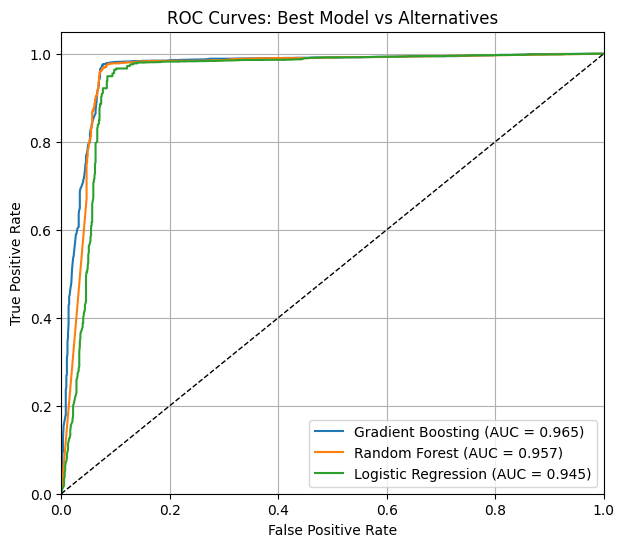

In [ ]:
from sklearn.metrics import roc_curve, auc


compare_configs = [
    ("Gradient Boosting", GradientBoostingClassifier(random_state=42),
     ['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 'Going_outside', 'Drained_after_socializing']),
    ("Random Forest", RandomForestClassifier(n_estimators=500, random_state=42),
     ['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 'Going_outside', 'Drained_after_socializing', 'Friends_circle_size']),
    ("Logistic Regression", Pipeline([
        ("sc", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
     ]),
     ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Drained_after_socializing'])
]

plt.figure(figsize=(7,6))
for name, model, feats in compare_configs:
    X = X_all[feats]
    X_train, X_test, y_train, y_test = train_test_split(X, y_all, test_size=0.2, random_state=42, stratify=y_all)
    if name == "Logistic Regression":
        from sklearn.pipeline import make_pipeline
        from sklearn.impute import SimpleImputer
        model = make_pipeline(SimpleImputer(strategy="constant", fill_value=0), StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
    else:
        model = Pipeline([
            ("imp", SimpleImputer(strategy="constant", fill_value=0)),
            ("clf", model)
        ])
    model.fit(X_train, y_train)
    y_score = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Best Model vs Alternatives')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Result

The results of the variable combination and model search show that the optimal combination is the **Gradient Boosting** model, using the following features:

1. **Time_spent_Alone** (time spent alone)
2. **Stage_fear** (stage fright)
3. **Social_event_attendance** (social event attendance)
4. **Going_outside** (frequency of going out)
5. **Drained_after_socializing** (energy depletion after socializing)

**AUC: 0.965**, indicating that the model and feature combination can accurately distinguish between introverts and extroverts.

**Interpretation of results:**
- These features cover multiple psychological and behavioral dimensions, such as social tendencies, comfort in public settings, and the impact of socializing on energy levels, providing a comprehensive reflection of an individual's personality traits.
- Gradient Boosting has advantages in handling non-linearity and feature interactions, such as identifying complex patterns such as “spends a lot of time alone but goes out frequently.”
- A high AUC indicates that the model not only performs well on the current data but also has the potential to maintain strong generalization ability in similar scenarios.

Overall, this combination achieves a good balance between feature number and model complexity, making it the optimal prediction solution for this task.


## Probelm 4

**Question 4**: Given their social behavior and personality traits, how can we predict whether a person is an introvert or extrovert?

**Step 1: DATA preprocessing**

In [ ]:
df_train04.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert


For this problem, we want to use all of the data in the dataset to predict. So we first fill all the missing value for the first 8 columns.

In [ ]:
numerical_cols_all = ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']
categorical_cols_all = ['Stage_fear', 'Drained_after_socializing']

for col in numerical_cols_all:
    median_val = df_train04[col].median()
    df_train04[col] = df_train04[col].fillna(median_val)

for col in categorical_cols_all:
    mode_val = df_train04[col].mode()[0]
    df_train04[col] = df_train04[col].fillna(mode_val)

df_train04.isnull().sum()

,0
id,0
Time_spent_Alone,0
Stage_fear,0
Social_event_attendance,0
Going_outside,0
Drained_after_socializing,0
Friends_circle_size,0
Post_frequency,0
Personality,0


Then, let's change the boolean data into numbers, for better classifing.

In [ ]:
df_train04['Stage_fear'] = df_train04['Stage_fear'].map({'No': 0, 'Yes': 1})
df_train04['Drained_after_socializing'] = df_train04['Drained_after_socializing'].map({'No': 0, 'Yes': 1})
df_train04['Personality'] = df_train04['Personality'].map({'Introvert': 0, 'Extrovert': 1})
df_train04.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,0,6.0,4.0,0,15.0,5.0,1
1,1,1.0,0,7.0,3.0,0,10.0,8.0,1
2,2,6.0,1,1.0,0.0,0,3.0,0.0,0
3,3,3.0,0,7.0,3.0,0,11.0,5.0,1
4,4,1.0,0,4.0,4.0,0,13.0,5.0,1


After moving the useless lines, we get our final dataset for this problem.

In [ ]:
df_train04 = df_train04.drop('id', axis=1)
df_train04.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0.0,0,6.0,4.0,0,15.0,5.0,1
1,1.0,0,7.0,3.0,0,10.0,8.0,1
2,6.0,1,1.0,0.0,0,3.0,0.0,0
3,3.0,0,7.0,3.0,0,11.0,5.0,1
4,1.0,0,4.0,4.0,0,13.0,5.0,1


**Step 2: EDA**

We want to predict the personality, so we first calculate the correlationship between personality and other independent variables.

In [ ]:
correlations = df_train04.corr()['Personality'].drop('Personality')
correlations_df = pd.DataFrame(correlations).rename(columns={'Personality': 'Correlation with Personality'})
correlations_df

,Correlation with Personality
Time_spent_Alone,-0.750859
Stage_fear,-0.816959
Social_event_attendance,0.674635
Going_outside,0.674389
Drained_after_socializing,-0.822843
Friends_circle_size,0.634583
Post_frequency,0.647048


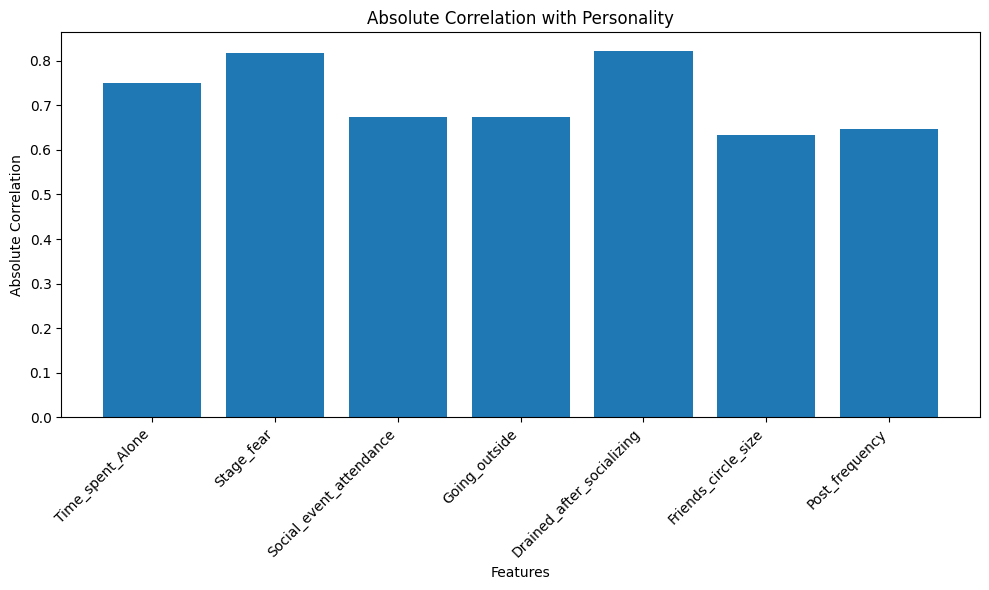

In [ ]:
correlations_abs = correlations_df['Correlation with Personality'].abs()

plt.figure(figsize=(10, 6))
plt.bar(correlations_abs.index, correlations_abs.values)
plt.title('Absolute Correlation with Personality')
plt.xlabel('Features')
plt.ylabel('Absolute Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Through the graph and the correlationship data frame. we can find out that all the independent variables have relatively high correlationship with the personality. So, it reasonable to train a model to predict whether a person is an extrovert or an introvert.

**Step 3: Modeling**

We want to build up three different models on this question to make reasonable prediction of the `Personality` based on all other independent variables.

We choose three different models here:

1. a K nearest neighbors classifier.
2. a **random forest** classifier (hyperparameter variable: n_trees, max_depth)
3. a small fully-connected **neural network** with 2-5 hidden layers and 5-10 hidden nodes in each layer.

**4.1 The K Nearest Neighbors Classifier**

Hyperparameters tuning: the number of neighbors, the distance metric.

In [ ]:
X = df_train04.drop('Personality', axis=1)
y = df_train04['Personality']

numerical_features = ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']
categorical_features = ['Stage_fear', 'Drained_after_socializing']

preprocessor = make_column_transformer(
    (StandardScaler(), numerical_features),
    (OneHotEncoder(), categorical_features))

knn_pipeline = make_pipeline(preprocessor, KNeighborsClassifier())

param_grid = {
    'kneighborsclassifier__n_neighbors': range(1, 30),
    'kneighborsclassifier__metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(knn_pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X, y)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Best parameters: {'kneighborsclassifier__metric': 'euclidean', 'kneighborsclassifier__n_neighbors': 21}
Best cross-validation accuracy: 0.9688515169798562


**4.2 The random forest classifier**

Hyperparameter tuning: the number of trees in the random forest and the max depth of the tree.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = make_pipeline(preprocessor, RandomForestClassifier(random_state=42))

param_grid_rf = {
    "randomforestclassifier__n_estimators": [100, 200, 500],
    "randomforestclassifier__max_depth": [None, 10, 20, 30],
}

grid_search_rf = GridSearchCV(
    rf_pipeline,
    param_grid_rf,
    scoring="accuracy",
    cv=5
)

grid_search_rf.fit(X, y)

print("Best parameters:", grid_search_rf.best_params_)
print("Best cross-validation accuracy:", grid_search_rf.best_score_)

Best parameters: {'randomforestclassifier__max_depth': 10, 'randomforestclassifier__n_estimators': 200}
Best cross-validation accuracy: 0.9685275574715156


**4.3 The full-connected neural network**

Hyperparameter tuning;

In [ ]:
from sklearn.neural_network import MLPClassifier

nn_pipeline = make_pipeline(preprocessor, MLPClassifier(max_iter=1000, random_state=42))

param_grid_nn = {
    "mlpclassifier__hidden_layer_sizes": [
        (5, 5),
        (10, 10),
        (5, 5, 5),
        (10, 10, 10),
        (5, 5, 5, 5),
        (10, 10, 10, 10),
        (5, 5, 5, 5, 5),
        (10, 10, 10, 10, 10),
        (5, 10, 5, 10),
        (10, 5, 10, 5),
        (5, 5, 10, 10, 5),
        (10, 10, 5, 5, 10),
    ],
    "mlpclassifier__activation": ["relu", "tanh"],
}

grid_search_nn = GridSearchCV(nn_pipeline, param_grid_nn, cv=5, scoring="accuracy")
grid_search_nn.fit(X, y)

print("Best parameters:", grid_search_nn.best_params_)
print("Best cross-validation accuracy:", grid_search_nn.best_score_)

Best parameters: {'mlpclassifier__activation': 'relu', 'mlpclassifier__hidden_layer_sizes': (10, 10, 5, 5, 10)}
Best cross-validation accuracy: 0.9691214079391868


In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

knn_predictions = cross_val_predict(grid_search.best_estimator_, X, y, cv=5)
rf_predictions = cross_val_predict(grid_search_rf.best_estimator_, X, y, cv=5)
nn_predictions = cross_val_predict(grid_search_nn.best_estimator_, X, y, cv=5)

knn_accuracy = accuracy_score(y, knn_predictions)
knn_precision = precision_score(y, knn_predictions)
knn_recall = recall_score(y, knn_predictions)
knn_f1 = f1_score(y, knn_predictions)

rf_accuracy = accuracy_score(y, rf_predictions)
rf_precision = precision_score(y, rf_predictions)
rf_recall = recall_score(y, rf_predictions)
rf_f1 = f1_score(y, rf_predictions)

nn_accuracy = accuracy_score(y, nn_predictions)
nn_precision = precision_score(y, nn_predictions)
nn_recall = recall_score(y, nn_predictions)
nn_f1 = f1_score(y, nn_predictions)

results_df_problem4 = pd.DataFrame({
    'Model': ['KNN Classifier', 'Random Forest Classifier', 'Neural Network Classifier'],
    'Accuracy': [knn_accuracy, rf_accuracy, nn_accuracy],
    'Precision': [knn_precision, rf_precision, nn_precision],
    'Recall': [knn_recall, rf_recall, nn_recall],
    'F1-score': [knn_f1, rf_f1, nn_f1]
})

display(results_df_problem4)

,Model,Accuracy,Precision,Recall,F1-score
0,KNN Classifier,0.968851,0.977302,0.980656,0.978976
1,Random Forest Classifier,0.968527,0.977015,0.980510,0.978759
2,Neural Network Classifier,0.969121,0.977728,0.980583,0.979153


Based on the results displayed in the DataFrame:

All three models—the KNN Classifier, Random Forest Classifier, and Neural Network Classifier—demonstrate exceptionally high and very similar performance across all evaluated metrics.

The Neural Network Classifier stands out as the top performer by a slight margin, achieving the highest Accuracy (0.969121) and F1-score (0.979153).

The KNN and Random Forest models also performed well, with their scores being nearly identical to those of the Neural Network. This indicates that any of the three models would be highly effective for this classification task, while the Neural Network is the best.

Notice: for question 3, we do not choose to do the cross validation for the model evaluation because of the limitted computing power.